
<!-- <h1><center><font size="5"> Emotion Analysis with LLMs </font></center></h1> -->

<h1 style="text-align: center;">Emotion Analysis with LLMs</h1>


<h2><center>Facebook-OPT, RoBERTa & ModernBERT</center></h2>

<h3><center> PEFT fine-tuning with Quantized LoRA </center></h3>

In [1]:
# Clean old installations
!pip uninstall -y peft torchao transformers accelerate -q

# utilities
!pip install -q evaluate scikit-posthocs
!pip install -U -q plotly kaleido
!plotly_get_chrome

# pinned, compatible training + quant/LoRA stack
!pip install -U -q "transformers==5.2.0" "peft==0.18.1" "accelerate==1.12.0" "torchao==0.16.0"


Plotly will install a copy of Google Chrome to be used for generating static images of plots.
Chrome will be installed at: None
Do you want to proceed? [y/n] y
Installing Chrome for Plotly...
Chrome installed successfully.
The Chrome executable is now located at: /usr/local/lib/python3.12/dist-packages/choreographer/cli/browser_exe/chrome-linux64/chrome


In [2]:
# Install necessary system-level libraries for Kaleido/Plotly
!sudo apt update && sudo apt-get install libnss3 libatk-bridge2.0-0 libcups2 libxcomposite1 libxdamage1 libxfixes3 libxrandr2 libgbm1 libxkbcommon0 libpango-1.0-0 libcairo2 libasound2

Hit:1 https://cloud.r-project.org/bin/linux/ubuntu jammy-cran40/ InRelease
Hit:2 https://developer.download.nvidia.com/compute/cuda/repos/ubuntu2204/x86_64  InRelease
Hit:3 https://cli.github.com/packages stable InRelease
Hit:4 http://archive.ubuntu.com/ubuntu jammy InRelease
Hit:5 http://security.ubuntu.com/ubuntu jammy-security InRelease
Hit:6 http://archive.ubuntu.com/ubuntu jammy-updates InRelease
Hit:7 https://ppa.launchpadcontent.net/deadsnakes/ppa/ubuntu jammy InRelease
Hit:8 http://archive.ubuntu.com/ubuntu jammy-backports InRelease
Hit:9 https://ppa.launchpadcontent.net/graphics-drivers/ppa/ubuntu jammy InRelease
Hit:10 https://r2u.stat.illinois.edu/ubuntu jammy InRelease
Hit:11 https://ppa.launchpadcontent.net/ubuntugis/ppa/ubuntu jammy InRelease
Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
99 packages can be upgraded. Run 'apt list --upgradable' to see them.
W: Skipping acquire of configured file 'main/source/Sources' as re

In [3]:
!nvidia-smi

Fri Mar  6 16:07:42 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA L4                      Off |   00000000:00:03.0 Off |                    0 |
| N/A   49C    P8             17W /   72W |       0MiB /  23034MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [4]:
from google.colab import drive
drive.mount('/gdrive', force_remount=True)
%cd /gdrive/MyDrive/nlp/qlora/

Mounted at /gdrive
/gdrive/MyDrive/nlp/qlora


In [5]:
# Connect to Hugging Face
from google.colab import userdata
HF_TOKEN = userdata.get('HF_TOKEN')

## 1. Setup

### 1.1 Main imports

In [6]:
# Enable GPU acceleration for Pandas (RAPIDS cuDF)
# %load_ext cudf.pandas

import gc

import numpy as np
import pandas as pd
from pathlib import Path
import torch
from torch.utils.data import DataLoader
from transformers import (Trainer, TrainingArguments)

from utilities.emotions_dataset import EmotionsDataset
from utilities.hf_pipeline import (build_tokenizer, lora_peft, seq_class_init,
                             collate_func, model_postprocessing)

seed = 1234
torch.manual_seed(seed)
np.random.seed(seed)

In [7]:
# Map device to the available device
device = torch.device('cuda') if torch.cuda.is_available() else torch.device('cpu')
device

device(type='cuda')

## 2. Emotions Datasets

### 2.1 About the Datasets



**`text.csv.zip`:**
The dataset comprises emotional content in text(tweets) and a single emotion label in integers. It contains a total of 416,808 tweets of emotional content. The emotions are classified into six categories: sadness (0), joy (1), love (2), anger (3), fear (4), and surprise (5).
The dataset can be sourced from:
https://www.kaggle.com/datasets/nelgiriyewithana/emotions/data

**`emotions.csv:`** The dataset comprises emotional content (tweets), tweet id, author, and a single categorical label per content id. It has in total 40,000 tweets of emotional content. A subset of this data was used in a project for Microsoft's Cortana Intelligence Gallery. The dataset was added to DataWorld on July 15, 2016, by CrowdFlower and can be sourced from: https://query.data.world/s/m3dkicscou2wd5p2d2ejd7ivfkipsg


### 2.2 Datasets Exploration & Cleanining


In [8]:
df = pd.read_csv('dataset/text.csv.zip', index_col=[0])
df.head()

,text,label
0,i just feel really helpless and heavy hearted,4
1,ive enjoyed being able to slouch about relax a...,0
2,i gave up my internship with the dmrg and am f...,4
3,i dont know i feel so lost,0
4,i am a kindergarten teacher and i am thoroughl...,4


In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 416809 entries, 0 to 416808
Data columns (total 2 columns):
 #   Column  Non-Null Count   Dtype 
---  ------  --------------   ----- 
 0   text    416809 non-null  object
 1   label   416809 non-null  int64 
dtypes: int64(1), object(1)
memory usage: 9.5+ MB


In [10]:
df.label.value_counts()

,count
label,
1,141067
0,121187
3,57317
4,47712
2,34554
5,14972


In [11]:
# Map label to emotion
label_to_emotion = {0: 'sadness', 1: 'joy', 2:'love', 3:'anger',
                    4:'fear', 5:'surprise'}

emotion_to_label = {v: k for k, v in label_to_emotion.items()}

In [12]:
df.describe()

,label
count,416809.000000
mean,1.554271
std,1.490453
min,0.000000
25%,0.000000
50%,1.000000
75%,3.000000
max,5.000000


In [13]:
unique_tweets = df.text.unique()
if len(unique_tweets) == df.shape[0]:
    print('No duplicated tweets')
else:
    print(f'Duplicated tweets: {df.shape[0] - len(unique_tweets)}')

Duplicated tweets: 22987


In [14]:
duplicates = df[df.duplicated(subset=['text'], keep=False)].index

In [12]:
print(f'Total duplicates: {len(duplicates)}')

Total duplicates: 45804


In [13]:
# Check if labels are consistent in duplicates
print('Checking for label consistency')

for idx in duplicates[0:4]:
    print(f'Tweet n: {idx}')
    print(df[df.text == df.iloc[idx].text])
    print("")


Checking for label consistency
Tweet n: 0
                                                 text  label
0       i just feel really helpless and heavy hearted      4
330710  i just feel really helpless and heavy hearted      0

Tweet n: 8
                                                     text  label
8       im forever taking some time out to have a lie ...      5
112706  im forever taking some time out to have a lie ...      4

Tweet n: 28
        text  label
28      when      3
183069  when      0
204577  when      4
244470  when      1

Tweet n: 34
                                                    text  label
34     i was less intelligent and could not really fe...      2
14054  i was less intelligent and could not really fe...      1



In [14]:
df_emotions = df[~df.duplicated(subset=['text'], keep=False)]

In [15]:
df_emotions.describe()

,label
count,371005.000000
mean,1.460740
std,1.453323
min,0.000000
25%,0.000000
50%,1.000000
75%,3.000000
max,5.000000


In [16]:
del df
gc.collect()

278

In [17]:
df_emotions = df_emotions.copy()
df_emotions.loc[:, 'emotions'] = df_emotions.loc[:, 'label'].map(label_to_emotion)

In [18]:
df_emotions.emotions.value_counts()

,count
emotions,
joy,129165
sadness,115868
anger,52262
fear,39554
love,24335
surprise,9821


In [19]:
df2 = pd.read_csv('dataset/text_emotion.csv')
df2.head()

,tweet_id,sentiment,author,content
0,1956967341,empty,xoshayzers,@tiffanylue i know i was listenin to bad habi...
1,1956967666,sadness,wannamama,Layin n bed with a headache ughhhh...waitin o...
2,1956967696,sadness,coolfunky,Funeral ceremony...gloomy friday...
3,1956967789,enthusiasm,czareaquino,wants to hang out with friends SOON!
4,1956968416,neutral,xkilljoyx,@dannycastillo We want to trade with someone w...


In [20]:
df2.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40000 entries, 0 to 39999
Data columns (total 4 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   tweet_id   40000 non-null  int64 
 1   sentiment  40000 non-null  object
 2   author     40000 non-null  object
 3   content    40000 non-null  object
dtypes: int64(1), object(3)
memory usage: 1.2+ MB


In [21]:
df2.drop(columns=['tweet_id', 'author'], inplace=True)

In [22]:
df2.describe()

,sentiment,content
count,40000,40000
unique,13,39827
top,neutral,I just received a mothers day card from my lov...
freq,8638,14


In [23]:
print(df2.sentiment.value_counts())

sentiment
neutral       8638
worry         8459
happiness     5209
sadness       5165
love          3842
surprise      2187
fun           1776
relief        1526
hate          1323
empty          827
enthusiasm     759
boredom        179
anger          110
Name: count, dtype: int64


In [24]:
df2_duplicates = df2[df2.duplicated(subset=['content'], keep=False)].index
print(f'Duplicates in dataworld dataset:{len(df2_duplicates)}')

Duplicates in dataworld dataset:262


In [25]:
# Check if labels are consistent in duplicates
print('Checking for label consistency')

for idx in df2_duplicates[0:4]:
    print(f'Tweet n: {idx}')
    print(df2[df2.content == df2.iloc[idx].content])
    print("")

Checking for label consistency
Tweet n: 51
     sentiment             content
51       worry  why am i so tired?
6954   neutral  why am i so tired?

Tweet n: 147
     sentiment      content
147     relief  I'm at work
1026   neutral  I'm at work

Tweet n: 324
    sentiment                             content
324   sadness  I feel so deflated. No more doggy.
366     worry  I feel so deflated. No more doggy.

Tweet n: 340
      sentiment content
340       empty       0
15028   neutral       0
29869   neutral       0
39415   neutral       0



In [26]:
df2_emotions = df2[~df2.duplicated(subset=['content'], keep=False) & df2.sentiment.isin(
                ['anger', 'fear', 'love', 'surprise'])]
df2_emotions.describe()

,sentiment,content
count,6057,6057
unique,3,6057
top,love,@mopedronin bullet train from tokyo the gf ...
freq,3770,1


In [27]:
del df2
gc.collect()

93

In [28]:
df2_emotions.sentiment.value_counts()

,count
sentiment,
love,3770
surprise,2177
anger,110


In [29]:
df2_emotions = df2_emotions.copy()
df2_emotions.loc[:, 'label'] = df2_emotions.loc[:, 'sentiment'].map(emotion_to_label)

In [30]:
df2_emotions.head()

,sentiment,content,label
14,surprise,Got the news,5
16,love,@annarosekerr agreed,2
94,love,@RobertF3 correct! I ADORE him. I just plucked...,2
122,love,@freepbx sounds good. Appreciate the suggestio...,2
131,love,Pats in philly at 2 am. I love it. Mmm cheeses...,2


In [ ]:
df_emotions.head()

,text,label,emotions
1,ive enjoyed being able to slouch about relax a...,0,sadness
2,i gave up my internship with the dmrg and am f...,4,fear
3,i dont know i feel so lost,0,sadness
4,i am a kindergarten teacher and i am thoroughl...,4,fear
5,i was beginning to feel quite disheartened,0,sadness


### 2.3 Combine Datasets – First Data Level Intervention

In [31]:
df2_emotions = df2_emotions.rename(columns={'sentiment': 'emotions', 'content':'text'})
df2_emotions.head()

,emotions,text,label
14,surprise,Got the news,5
16,love,@annarosekerr agreed,2
94,love,@RobertF3 correct! I ADORE him. I just plucked...,2
122,love,@freepbx sounds good. Appreciate the suggestio...,2
131,love,Pats in philly at 2 am. I love it. Mmm cheeses...,2


In [32]:
df_emotions = pd.concat([df_emotions, df2_emotions[['text', 'label', 'emotions']]], ignore_index=True)

In [33]:
df_emotions.emotions.value_counts()

,count
emotions,
joy,129165
sadness,115868
anger,52372
fear,39554
love,28105
surprise,11998


In [ ]:
df_emotions.to_csv('dataset/merged_emot_dataset.csv')

### 2.4 Visualise Emotions Distribution

In [15]:
import plotly.io as pio
pio.get_chrome()
import plotly.express as px
pio.renderers

Renderers configuration
-----------------------
    Default renderer: 'colab'
    Available renderers:
        ['plotly_mimetype', 'jupyterlab', 'nteract', 'vscode',
         'notebook', 'notebook_connected', 'kaggle', 'azure', 'colab',
         'cocalc', 'databricks', 'json', 'png', 'jpeg', 'jpg', 'svg',
         'pdf', 'browser', 'firefox', 'chrome', 'chromium', 'iframe',
         'iframe_connected', 'sphinx_gallery', 'sphinx_gallery_png']

In [16]:
plot_dir = Path('results/plots')
plot_dir.mkdir(parents=True, exist_ok=True)

In [36]:
pio.renderers.default = "colab" # "notebook+colab+svg+notebook_connected+browser"

In [ ]:
# Show dataset distribution
fig = px.bar(df_emotions.emotions.value_counts().reset_index(), x='emotions', y='count',
            title='Emotions distributions', width=500, height=400, template='simple_white',
            color_discrete_sequence=['#088F8F'],
            labels={'emotions': 'Emotions',
                     'count': 'Frequency'})
fig.update_yaxes(showgrid=True)
fig.write_image('results/plots/emotions_distribution.svg', format='svg')
fig.show()

In [37]:
df_emotions.emotions.value_counts()/df_emotions.label.value_counts().max()*100

,count
emotions,
joy,100.000000
sadness,89.705416
anger,40.546588
fear,30.622847
love,21.758990
surprise,9.288894


In [38]:
df_emotions.emotions.value_counts().sum()

np.int64(377062)

- Unbalanced dataset
- Majority classes: joy and sadness
- Minority classes: anger, fear, love, surprise with fewer than 80% instances than the majority class

In [39]:
import matplotlib.pyplot as plt
import spacy
from wordcloud import WordCloud, STOPWORDS


In [40]:
# Load the model
nlp = spacy.load('en_core_web_sm', disable=['parser', 'ner', 'lemmatizer'])

def preprocess_dataframe(data, text_col):

    clean_texts = []
    # Using nlp.pipe for maximum speed on 500k rows
    for doc in nlp.pipe(data[text_col].astype(str), batch_size=1000):
        # Extract nouns and adjectives
        words = [token.text.lower() for token in doc if token.pos_ in ['NOUN', 'ADJ']]
        clean_texts.append(" ".join(words))

    data['cleaned_tokens'] = clean_texts
    return data

In [42]:
df_processed = preprocess_dataframe(df_emotions, 'text')


In [43]:
def fast_word_cloud(data, emot_col, emot_list, rows=2, cols=3, out_dir=plot_dir):

    tweet_col = 'cleaned_tokens'

    fig, axes = plt.subplots(nrows=rows, ncols=cols, figsize=(7, 10))
    plt.subplots_adjust(hspace=0.1, wspace=0.1)
    axes_flat = axes.flatten()

    # Standard stopwords (we already filtered most noise with POS tagging)
    stop_words = set(STOPWORDS).union({'im', 'feel', 'feeling', 'like'})

    for i, em in enumerate(emot_list):
        if i < len(axes_flat):
            ax = axes_flat[i]

            # Since data is pre-cleaned, we just join the strings
            text_data = " ".join(data[data[emot_col] == em][tweet_col].astype(str))

            if text_data.strip():
                w_cloud = WordCloud(
                    width=600, height=600,
                    background_color='black',
                    stopwords=stop_words,
                    max_font_size=100,
                    max_words=80,
                    collocations=False
                ).generate(text_data)

                ax.imshow(w_cloud, interpolation='bilinear', aspect='equal')
                ax.set_title(f'Emotion: {em}', fontsize=12)
                ax.axis('off')

                plt.figure(figsize=(5, 5))
                plt.imshow(w_cloud, interpolation='bilinear')
                plt.axis('off')
                plt.savefig(f'{out_dir}/wordcloud_{em}.svg', format='svg',
                            facecolor='black', pad_inches=0)
                plt.close()

    plt.tight_layout(pad=3.0)
    plt.show()

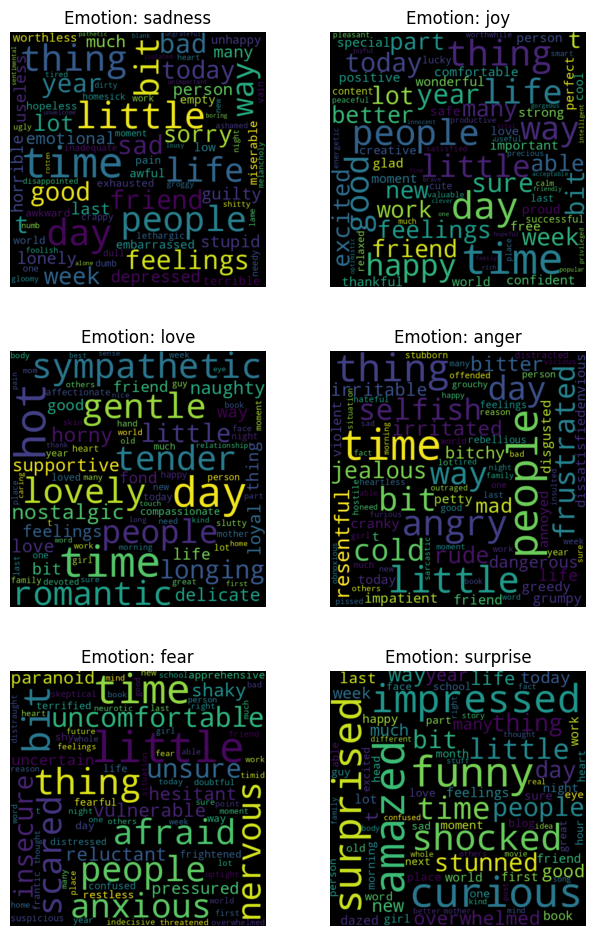

In [ ]:
fast_word_cloud(df_processed, emot_col='emotions',
           emot_list=emotion_to_label.keys(), rows=3, cols=2, out_dir=plot_dir)

## 3. Split Dataset

In [44]:
from sklearn.model_selection import train_test_split
from utilities.balance_dataset import combined_cat_sampling

### 3.1 Split Dataset

In [45]:
train, validation = train_test_split(df_emotions,  test_size=0.40,
                                      stratify=df_emotions.label, random_state=seed)

In [46]:
validation, test = train_test_split(validation, test_size=0.50, stratify=validation.label,
                                    random_state=seed)

In [47]:
train.emotions.value_counts()

,count
emotions,
joy,77499
sadness,69521
anger,31423
fear,23732
love,16863
surprise,7199


In [48]:
train.label.value_counts()/train.label.value_counts().max()*100

,count
label,
1,100.000000
0,89.705674
3,40.546330
4,30.622331
2,21.758990
5,9.289152


### 3.2 Resampling the Training Set - Second Data Level Intervention

The minority class is ~ 9.3 % of the majority group size. We will partially balance the dataset using oversampling and undersampling techniques. The resampling techniques will aim to increase the minority classes and undersample the majority classes without causing a drastic change to the original train set data distribution.

**Oversampling emotions:**
- suprise
- love
- fear

**Undersampling emotions:**
- joy
- sadness


In [49]:
oversampling = {3:35000, 4: 30000, 2:25000, 5:13800}
undersampling = {0: 57800, 1: 65000}

In [50]:
x_train = np.array(train.text.values).reshape(-1,1)

In [51]:
x_resample, y_resample = combined_cat_sampling(x_train, train.label, seed, oversampling, undersampling)

In [52]:
y_resample.value_counts()

,count
label,
1,65000
0,57800
3,35000
4,30000
2,25000
5,13800


In [53]:
y_resample.value_counts()/ y_resample.value_counts()[1]

,count
label,
1,1.000000
0,0.889231
3,0.538462
4,0.461538
2,0.384615
5,0.212308


In [56]:
fig_re = px.bar(x=[label_to_emotion[k] for k in y_resample.value_counts().index],
                y=list(y_resample.value_counts().values),
            title='Emotions distributions in the train dataset resampling', width=600, height=400, template='simple_white',
            color_discrete_sequence=['#088F8F'],
            labels={'x': 'Emotions"',
                     'y': 'Frequency'})
fig_re.update_yaxes(showgrid=True)
fig_re.write_image('results/plots/emotion_train_distribution.svg', format='svg')
fig_re.show()


### 3.3 Data Persistence

In [57]:
train_dataset = pd.DataFrame({'text':x_resample.reshape(-1), 'label':y_resample,
                              'emotions':[label_to_emotion[lb] for lb in y_resample]})
train_dataset.to_csv('dataset/train_dataset.csv', index=False)

In [ ]:
validation.to_csv('dataset/val_dataset.csv', index=False)
test.to_csv('dataset/test_dataset.csv', index=False)

In [58]:
del df_emotions, train_dataset, validation, x_resample, y_resample, test
gc.collect()

12617

## 4. Prepare for Training

In [19]:
import multiprocessing
multiprocessing.cpu_count()

12

In [60]:
train = pd.read_csv('dataset/train_dataset.csv')
validation = pd.read_csv("dataset/val_dataset.csv")

### 4.1 Weighted Cross Entropy – In process Intervention

To prevent the algorithms greedily predicting the one of majority classes, we will use a weighted loss during training.

In [61]:
from peft.utils import constants
from functools import partial
from utilities.weighted_loss import create_weights, weighted_ce_loss
from utilities.hf_pipeline import quantization_report


In [62]:
# List emotions
emot_list = list(emotion_to_label.keys())

# Built Weighted Cross Entropy loss function
weights = create_weights(labels=train.label.values)

In [63]:
# Auto-detect the best precision for your Colab GPU
use_bf16 = torch.cuda.is_bf16_supported()

### 4.2 Built Functions

In [64]:
from peft import get_peft_model
from utilities.eval_metrics import class_metrics

In [65]:
# Main experiment function
def main(trainer_args, **kwargs):

    name = kwargs['check_point'].split('/')[-1].lower()

    trainer_args.output_dir = f'{kwargs["output_dir"]}/peft-{name}'
    trainer_args.logging_dir = f'{kwargs["output_dir"]}/peft-{name}/logs'

    tokenizer = build_tokenizer(kwargs['check_point'])

    train_dataset = EmotionsDataset(kwargs['x_train'], kwargs['y_train'], tokenizer, kwargs['max_length'])
    val_dataset = EmotionsDataset(kwargs['x_val'], kwargs['y_val'], tokenizer, kwargs['max_length'])

    data_collator = collate_func(tokenizer=tokenizer)

    model = seq_class_init(kwargs['check_point'],
                           num_labels=kwargs['num_labels'],
                           id2label=kwargs['id2label'],
                           label2id=kwargs['label2id'], device=kwargs['device'],
                           quantized=kwargs['quantized'])

    model = model_postprocessing(model)

    if 'modernbert' in name:
        target_modules = ['Wqkv', 'Wo', 'Wi']
    else:
        target_modules_map = constants.TRANSFORMERS_MODELS_TO_LORA_TARGET_MODULES_MAPPING
        target_modules = target_modules_map[name.split('-')[0]]

    peft_config = lora_peft(target_modules=target_modules)
    peft_config.inference_mode = False

    peft_model = get_peft_model(model, peft_config)

    peft_model.config.use_cache = False


    llm_trainer = Trainer(
    model=peft_model,
    args=trainer_args,
    compute_loss_func=partial(weighted_ce_loss, weights=weights),
    train_dataset=train_dataset,
    eval_dataset=val_dataset,
    processing_class=tokenizer,
    data_collator=data_collator,
    compute_metrics=class_metrics)

    print("")

    if kwargs.get('quantized'):
        quantization_report(llm_trainer.model)
        peft_type = 'PEFT-QLoRA'
        print("")

    else:
        peft_type = 'PEFT-QLoRA'

    print(f"{peft_type} {name.capitalize()} Model:")

    llm_trainer.model.print_trainable_parameters()

    return llm_trainer


### 4.3 Set Training Arguments and Parameter

In [66]:
training_args = TrainingArguments(
    output_dir=None,
    learning_rate=1e-4,
    eval_strategy='steps',
    eval_steps= 1400,
    num_train_epochs=1,
    bf16=use_bf16,
    fp16=not use_bf16,
    use_cpu=True if device.type == 'cpu' else False,
    dataloader_num_workers=4,
    per_device_train_batch_size=8,
    per_device_eval_batch_size=8,
    gradient_accumulation_steps=4,
    train_sampling_strategy = 'group_by_length',
    logging_steps = 100,
    weight_decay=0.05,
    save_strategy='steps',
    save_steps = 1400,
    save_total_limit=1,
    metric_for_best_model='f1',
    greater_is_better=True,
    load_best_model_at_end=True,
    report_to='none' # comet_ml, clearml, mlflow, swanlab, tensorboard, and wandb
)

In [67]:
check_points = ['roberta-base', 'facebook/opt-350m', 'answerdotai/ModernBERT-base']

In [68]:
params = {'check_point': check_points[0], 'quantized': True,
          'num_labels': len(emot_list),'x_train':train.text.values,  'y_train': train.label.values,'x_val': validation.text.values, 'y_val': validation.label.values,'max_length': 128,
          'id2label': label_to_emotion, 'label2id': emotion_to_label,
          'device': device, 'output_dir': 'results/weights/q8intlora'}

## 5. Start Training

### 5.1 RoBERTa

In [23]:
train_roberta = main(training_args, **params)

config.json:   0%|          | 0.00/481 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/499M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

RobertaForSequenceClassification LOAD REPORT from: roberta-base
Key                             | Status     | 
--------------------------------+------------+-
roberta.embeddings.position_ids | UNEXPECTED | 
lm_head.dense.weight            | UNEXPECTED | 
lm_head.bias                    | UNEXPECTED | 
lm_head.layer_norm.weight       | UNEXPECTED | 
lm_head.layer_norm.bias         | UNEXPECTED | 
lm_head.dense.bias              | UNEXPECTED | 
classifier.out_proj.weight      | MISSING    | 
classifier.dense.weight         | MISSING    | 
classifier.dense.bias           | MISSING    | 
classifier.out_proj.bias        | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.




📊 Model Quantization Report
Total Modules:          478
Linear Layers:          124
   ├─  Int8 Base:       72
   ├─  LoRA:            48
   └─  Head:            4
 Est. VRAM (Weights):   329.66 MiB


PEFT-QLoRA Roberta-base Model:
trainable params: 890,118 || all params: 125,540,364 || trainable%: 0.7090


In [ ]:
train_roberta.train()

Step,Training Loss,Validation Loss,Accuracy,Matthews Correlation,F1,Precision,Recall
1400,1.189199,0.231781,0.921617,0.897742,0.896781,0.872615,0.926970
2800,0.678563,0.139499,0.962062,0.949722,0.943786,0.933166,0.956677
4200,0.602909,0.109823,0.969567,0.959672,0.955788,0.949090,0.962944
5600,0.563211,0.095102,0.974235,0.965785,0.960211,0.953935,0.967169
7000,0.521607,0.093318,0.974513,0.966156,0.960855,0.955033,0.967081


TrainOutput(global_step=7082, training_loss=0.982519393787314, metrics={'train_runtime': 4894.3576, 'train_samples_per_second': 46.298, 'train_steps_per_second': 1.447, 'total_flos': 2621886414450048.0, 'train_loss': 0.982519393787314, 'epoch': 1.0})

In [ ]:
train_roberta.push_to_hub()

Processing Files (0 / 0)      : |          |  0.00B /  0.00B            

New Data Upload               : |          |  0.00B /  0.00B            

  ...ckpoint-7082/optimizer.pt:   0%|          | 12.2kB / 7.17MB            

  ...ckpoint-7000/optimizer.pt:   0%|          | 12.2kB / 7.17MB            

  ...adapter_model.safetensors:   2%|2         | 79.5kB / 3.57MB            

...

  ...nt-7000/training_args.bin:   2%|2         |   117B / 5.26kB            

  ...adapter_model.safetensors:   2%|2         | 79.5kB / 3.57MB            

  ...kpoint-7082/rng_state.pth:   2%|2         |   326B / 14.6kB            

  ...ckpoint-7082/scheduler.pt:   2%|2         |  32.0B / 1.47kB            

CommitInfo(commit_url='https://huggingface.co/Wb-az/peft-roberta-base/commit/379d0d5d0b45657b0ed3c50fe7185870fdcffdb0', commit_message='End of training', commit_description='', oid='379d0d5d0b45657b0ed3c50fe7185870fdcffdb0', pr_url=None, repo_url=RepoUrl('https://huggingface.co/Wb-az/peft-roberta-base', endpoint='https://huggingface.co', repo_type='model', repo_id='Wb-az/peft-roberta-base'), pr_revision=None, pr_num=None)

In [ ]:
print(f"Total training time: {train_roberta.state.log_history[-1]['train_runtime']} seconds")

Total training time: 4894.3576 seconds


In [ ]:
# Get the path to the best adapter
rlq_weights = train_roberta.state.best_model_checkpoint
rlq_weights

'results/weights/q8intlora/peft-roberta-base/checkpoint-7000'

### 5.1.1 Training Loss Visualisation

In [ ]:
from utilities.eval_metrics import plot_loss

In [ ]:
plot_loss(train_roberta.state.log_history, 'qlora_roberta', plot_dir)

In [2]:
del train_roberta
torch.cuda.empty_cache()

### 5.2 Opt

In [ ]:
# Update the checkpoint to opt-350m
params['check_point'] = check_points[1]
train_opt = main(training_args, **params)

Loading weights:   0%|          | 0/388 [00:00<?, ?it/s]

OPTForSequenceClassification LOAD REPORT from: facebook/opt-350m
Key          | Status  | 
-------------+---------+-
score.weight | MISSING | 

Notes:
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.




📊 Model Quantization Report
Total Modules:          758
Linear Layers:          244
   ├─  Int8 Base:       146
   ├─  LoRA:            96
   └─  Head:            2
 Est. VRAM (Weights):   581.01 MiB


PEFT-QLoRA Opt-350m Model:
trainable params: 789,504 || all params: 331,988,992 || trainable%: 0.2378


In [ ]:
train_opt.train()

Step,Training Loss,Validation Loss,Accuracy,Matthews Correlation,F1,Precision,Recall
1400,4.326871,0.587165,0.872872,0.833633,0.824786,0.805718,0.856604
2800,3.342051,0.479850,0.959900,0.946859,0.938723,0.929815,0.949413
4200,1.399690,0.290365,0.970350,0.960847,0.948750,0.950202,0.950804
5600,1.142428,0.185262,0.976158,0.968429,0.957676,0.949545,0.968760
7000,0.851983,0.105398,0.980772,0.974447,0.965413,0.961951,0.969081


TrainOutput(global_step=7082, training_loss=5.126705715327033, metrics={'train_runtime': 9349.6437, 'train_samples_per_second': 24.236, 'train_steps_per_second': 0.757, 'total_flos': 8801128399405056.0, 'train_loss': 5.126705715327033, 'epoch': 1.0})

In [ ]:
train_opt.push_to_hub()

Processing Files (0 / 0)      : |          |  0.00B /  0.00B            

New Data Upload               : |          |  0.00B /  0.00B            

  ...adapter_model.safetensors:  17%|#6        |  538kB / 3.17MB            

  ...pt-350m/training_args.bin:  17%|#6        |   894B / 5.26kB            

CommitInfo(commit_url='https://huggingface.co/Wb-az/peft-opt-350m/commit/4dfb1cea0dac0e27ef7abb1f285594391b3651ac', commit_message='End of training', commit_description='', oid='4dfb1cea0dac0e27ef7abb1f285594391b3651ac', pr_url=None, repo_url=RepoUrl('https://huggingface.co/Wb-az/peft-opt-350m', endpoint='https://huggingface.co', repo_type='model', repo_id='Wb-az/peft-opt-350m'), pr_revision=None, pr_num=None)

In [ ]:
print(f"Total training time: {train_opt.state.log_history[-1]['train_runtime']} seconds")

Total training time: 9349.6437 seconds


In [ ]:
# Get the path to the best adapter
opt_lq_weights = train_opt.state.best_model_checkpoint
opt_lq_weights

'results/weights/q8intlora/peft-opt-350m/checkpoint-7000'

### 5.2.1 Training Loss Visualisation

In [ ]:
plot_loss(train_opt.state.log_history, 'qlora_opt', plot_dir)

In [ ]:
del train_opt,
torch.cuda.empty_cache()

### 5.3 ModernBERT

In [ ]:
params['check_point'] = check_points[2]
train_mbert = main(training_args, **params)


Loading weights:   0%|          | 0/136 [00:00<?, ?it/s]

ModernBertForSequenceClassification LOAD REPORT from: answerdotai/ModernBERT-base
Key               | Status     | 
------------------+------------+-
decoder.bias      | UNEXPECTED | 
classifier.bias   | MISSING    | 
classifier.weight | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.




📊 Model Quantization Report
Total Modules:          1164
Linear Layers:          267
   ├─  Int8 Base:       88
   ├─  LoRA:            176
   └─  Head:            3
 Est. VRAM (Weights):   429.48 MiB


PEFT-QLoRA Modernbert-base Model:
trainable params: 1,694,214 || all params: 151,303,692 || trainable%: 1.1197


In [ ]:
train_mbert.train()

Step,Training Loss,Validation Loss,Accuracy,Matthews Correlation,F1,Precision,Recall
1400,0.534775,0.096758,0.972179,0.963065,0.956765,0.952781,0.960870
2800,0.297524,0.072802,0.980812,0.974532,0.963742,0.955877,0.972465
4200,0.238529,0.051771,0.986501,0.982061,0.973064,0.968506,0.977991
5600,0.250038,0.044340,0.988172,0.984278,0.975242,0.970855,0.980343
7000,0.196784,0.041003,0.988702,0.984974,0.975989,0.972989,0.979174


TrainOutput(global_step=7082, training_loss=0.5938445644437913, metrics={'train_runtime': 10209.8948, 'train_samples_per_second': 22.194, 'train_steps_per_second': 0.694, 'total_flos': 3454708021918272.0, 'train_loss': 0.5938445644437913, 'epoch': 1.0})

In [ ]:
train_mbert.push_to_hub()

Processing Files (0 / 0)      : |          |  0.00B /  0.00B            

New Data Upload               : |          |  0.00B /  0.00B            

  ...adapter_model.safetensors:   8%|8         |  547kB / 6.80MB            

  ...rt-base/training_args.bin:   8%|8         |   423B / 5.26kB            

CommitInfo(commit_url='https://huggingface.co/Wb-az/peft-modernbert-base/commit/33ea847843cc488af42ec2309beb2fc091cf9740', commit_message='End of training', commit_description='', oid='33ea847843cc488af42ec2309beb2fc091cf9740', pr_url=None, repo_url=RepoUrl('https://huggingface.co/Wb-az/peft-modernbert-base', endpoint='https://huggingface.co', repo_type='model', repo_id='Wb-az/peft-modernbert-base'), pr_revision=None, pr_num=None)

In [ ]:
print(f"Total training time: {train_mbert.state.log_history[-1]['train_runtime']} seconds")

Total training time: 10209.8948 seconds


In [ ]:
# Get the path to the best adapter
mbql_weights = train_mbert.state.best_model_checkpoint
mbql_weights

'results/weights/q8intlora/peft-modernbert-base/checkpoint-7000'

### 5.3.1 Training Loss Visualisation

In [ ]:
plot_loss(train_mbert.state.log_history, 'qlora_mbert_base', plot_dir)

In [ ]:
del train_mbert
torch.cuda.empty_cache()

In [29]:
del train, validation, weights

## 6. Inference

In [20]:
from transformers import logging
logging.set_verbosity_error()

In [21]:
from utilities.eval_metrics import class_report_df, plot_confusion_matrix, metrics_summary
from utilities.hf_pipeline import inf_predictions

In [22]:
emot_list = list(emotion_to_label.keys())
metrics_dir = Path('results/metrics')
metrics_dir.mkdir(parents=True, exist_ok=True)

In [23]:
inf_dir = {'num_labels': len(emot_list), 'label2id':emotion_to_label,
           'id2label':label_to_emotion, 'device':device,
           'quantized': False, 'max_length': 128, 'batch':32}

In [24]:
test = pd.read_csv('dataset/test_dataset.csv')

In [25]:
x_test = test.text.values
y_test = test.label.values

### 6.1 RoBERTa-LoRA

In [55]:
peft_path = 'results/weights/q8intlora/peft-roberta-base/checkpoint-7000'


In [56]:
out, peftmodel, base_name = inf_predictions(peft_path, x_test, y_test, **inf_dir)

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

100%|██████████| 2357/2357 [01:36<00:00, 24.53it/s]


In [57]:
lb, rob_pred = out[0], out[1]

In [58]:
# Classification Report
rob_report = class_report_df(lb, rob_pred, mapping_dict=label_to_emotion,
                             output_dict=True, m_name='qlora_roberta_base',
                             save_path='results/metrics')
print('Classification Report: LoRA-RoBERTa-base\n')
print(rob_report)

Classification Report: LoRA-RoBERTa-base

         Metric Precision Recall  F1-score  Support
0       sadness      0.98   0.98      0.98    23174
1           joy      0.99   0.98      0.98    25833
2          love      0.95   0.96      0.95     5621
3         anger      0.97   0.98      0.97    10475
4          fear      0.97   0.98      0.97     7911
5      surprise      0.88   0.94      0.91     2399
6      accuracy         -      -      0.98    75413
7     macro avg      0.96   0.97      0.96    75413
8  weighted avg      0.98   0.98      0.98    75413


In [59]:
# Plot Confusion Matrix
print('Confusion Matrix: Lora-RoBERTa-base\n')
plot_confusion_matrix(lb, rob_pred, classes=emot_list,
                      image_name='rob_infer_cm', outdir=plot_dir)

Confusion Matrix: Lora-RoBERTa-base



In [91]:
metrics_dir = Path('results/metrics')
metrics_dir.mkdir(parents=True, exist_ok=True)

In [83]:
rboots_metrics = metrics_summary(lb, rob_pred, rounds=1000, model_name=f'qlora-{base_name}')
rboots_metrics

average    median  ci_lower  \
model              metric                                               
qlora-roberta-base accuracy              0.976168  0.976184  0.975070   
                   precision             0.967854  0.967864  0.965776   
                   recall                0.956883  0.956900  0.954429   
                   f1                    0.962222  0.962253  0.960148   
                   matthews_correlation  0.968349  0.968371  0.966879   

                                         ci_upper  
model              metric                          
qlora-roberta-base accuracy              0.977219  
                   precision             0.969957  
                   recall                0.959366  
                   f1                    0.964396  
                   matthews_correlation  0.969721

In [94]:
rboots_metrics.to_csv(metrics_dir / f'bs-qlora-{base_name}.csv')

### 6.2 Opt-350m-LoRA

In [48]:
peft_path_opt = 'results/weights/q8intlora/peft-opt-350m'

In [49]:
out, opt_peftmodel, _ = inf_predictions(peft_path_opt, x_test, y_test, **inf_dir)

Loading weights:   0%|          | 0/388 [00:00<?, ?it/s]

100%|██████████| 2357/2357 [01:23<00:00, 28.26it/s]


In [50]:
lb, opt_pred = out[0], out[1]

In [51]:
# Classification report
m_name='qlora-opt-350'
opt_report = class_report_df(lb, opt_pred, mapping_dict=label_to_emotion,
                             output_dict=True, m_name=m_name,
                             save_path=metrics_dir)
print('Classification Report: Lora-Opt-350m\n')
print(opt_report)


Classification Report: Lora-Opt-350m

         Metric Precision Recall  F1-score  Support
0       sadness      0.99   0.99      0.99    23174
1           joy      0.99   0.99      0.99    25833
2          love      0.96   0.96      0.96     5621
3         anger      0.98   0.97      0.98    10475
4          fear      0.95   0.99      0.97     7911
5      surprise       0.9   0.93      0.91     2399
6      accuracy         -      -      0.98    75413
7     macro avg      0.96   0.97      0.97    75413
8  weighted avg      0.98   0.98      0.98    75413


In [52]:
# Plot Confusion Matrix
print('Confusion Matrix: Lora-Opt-350m\n')
plot_confusion_matrix(lb, opt_pred, classes=emot_list,
                      image_name=f'{m_name}_inf', outdir=plot_dir)


Confusion Matrix: Lora-Opt-350m



In [53]:
# Bootstrap metrics with confidence intervals
opt_boots_metrics = metrics_summary(lb, opt_pred, rounds=1000, model_name=m_name)
opt_boots_metrics

average    median  ci_lower  ci_upper
model         metric                                                      
qlora-opt-350 accuracy              0.981121  0.981104  0.980202  0.982112
              precision             0.969692  0.969693  0.967569  0.971711
              recall                0.963248  0.963247  0.960765  0.965609
              f1                    0.966390  0.966389  0.964253  0.968490
              matthews_correlation  0.974917  0.974902  0.973687  0.976250

In [54]:
opt_boots_metrics.to_csv(metrics_dir / f'bs-qlora-{m_name}.csv')

### 6.3 ModernBERT-LoRA

In [26]:
peft_path_mbert = 'results/weights/q8intlora/peft-modernbert-base/checkpoint-7000'

In [27]:
out, mbert_peftmodel, mbert_name = inf_predictions(peft_path_mbert,
                                                    x_test, y_test, **inf_dir)

Loading weights:   0%|          | 0/136 [00:00<?, ?it/s]

100%|██████████| 2357/2357 [03:00<00:00, 13.02it/s]


In [28]:
lb, mbert_pred = out[0], out[1]

In [40]:
m_name = 'modernbert-base'
mbert_report = class_report_df(lb, mbert_pred, mapping_dict=label_to_emotion,
                             output_dict=True, m_name=m_name,
                             save_path=metrics_dir)
print('Classification Report: ModernBERT-base\n')
print(mbert_report)

         Metric Precision Recall  F1-score  Support
0       sadness       1.0   0.99      0.99    23174
1           joy       1.0    1.0      1.00    25833
2          love      0.97   0.96      0.97     5621
3         anger      0.98   0.99      0.99    10475
4          fear      0.99   0.98      0.99     7911
5      surprise       0.9   0.95      0.92     2399
6      accuracy         -      -      0.99    75413
7     macro avg      0.97   0.98      0.98    75413
8  weighted avg      0.99   0.99      0.99    75413


In [41]:
# Plot Confusion Matrix
print('Confusion Matrix: ModernBERT-base\n')
plot_confusion_matrix(lb, mbert_pred, classes=emot_list,
                      image_name=f'{m_name}_inf', outdir=plot_dir)

Confusion Matrix: ModernBERT-base



In [44]:
# Bootstrap metrics with confidence intervals
mbert_boots_metrics = metrics_summary(lb, mbert_pred, rounds=1000, model_name=f'{m_name}')
mbert_boots_metrics

average    median  ci_lower  ci_upper
model           metric                                                      
modernbert-base accuracy              0.988655  0.988649  0.987907  0.989378
                precision             0.979055  0.979056  0.977252  0.980834
                recall                0.972683  0.972704  0.970472  0.974824
                f1                    0.975743  0.975748  0.973785  0.977651
                matthews_correlation  0.984911  0.984905  0.983919  0.985868

In [45]:
mbert_boots_metrics.to_csv(metrics_dir /f'bs-qlora-{m_name}.csv')

In [47]:
torch.cuda.empty_cache()

- Bootstrap predictions to get confidence intervals for the test metrics: accuracy, f1, recall, precision, and Matthew's correlation coefficient.
- Convert predictions to binary class 1 to predictions that match the true value, and 0 for no matches.
- Run omnibus test Cochran's q-test.
- If the $H_0$ is rejected, then follow a pairwise comparison with McNemar and with Holm correction.
- Terminate comparison if failing to reject $H_0$.
- Get model directions and plot results.

In [106]:
from utilities.stats_tools import class_model_comparison


In [107]:
binary_res = pd.DataFrame({'mbert':(mbert_pred == lb).astype(int),
                              'opt': (opt_pred == lb).astype(int),
                              'roberta': (rob_pred == lb).astype(int)})


Cochran's Q Statistic: 655.5977
P-value: 0.0000

Result is Significant: At least one model performs differently.
Proceed to pairwise McNemar tests to find the best model(s).
Initiating posthoc McNemar pair-wise comparison


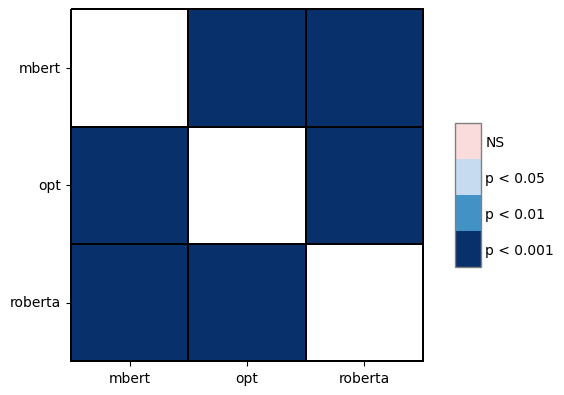

In [108]:
plot_args = {'outdir':plot_dir, 'show':True, 'size':None}
model_comp, diff_dir = class_model_comparison(binary_res, plot=True, **plot_args)

In [109]:
diff_dir

,mbert,opt,roberta
mbert,0.000000,0.007532,0.012504
opt,-0.007532,0.000000,0.004973
roberta,-0.012504,-0.004973,0.000000


As per the **Cochran's Q test** and the **McNemar** pair-wise model comparison, we can conclude that the performance of the three models is significantly different.

The direction matrix shows ModernBERT dominates OPT-350 and RoBERTa:

- ModernBERT vs OPT = +0.007532 
- ModernBERT vs RoBERTa = +0.012504 
- OPT vs RoBERTa = +0.004973

ModernBERT $\succ$ OPT $\succ$ RoBERTa
  
Ranking by pairwise net accuracy advantage:
1. ModernBERT
2. OPT 
3. RoBERTa


| Model      | Low confidence<br/> MCC | Upper Confidence<br/> MCC | Training Time (hh:mm:ss) | Precision Minority <br/>Classes love/surprise |
|------------|-------------------------|---------------------------|--------------------------|-----------------------------------------------|
| RoBERTa    | 0.9669                  | 0.9697                    | 1:21:33                  | 0.95 / 0.88                                   |
| Opt-350    | 0.9737                  | 0.9763                    | 2:35:48                  | 0.96 / 0.9                                    |
| ModernBERT | 0.9839                  | 0.9859                    | 2:50:08                  | 0.97 / 0.9                                    |

## 8. Sample random prediction

In [64]:
random_sample = np.random.randint(0, len(x_test), 5)

for i in random_sample:

    print(f'Tweet: {x_test[i]}')
    print(f'Emotion: {label_to_emotion[y_test[i]]}')
    print('')
    print(f'Opt-350 predicted: {label_to_emotion[opt_pred[i]]}')
    print(f'ModernBERT-base predicted: {label_to_emotion[mbert_pred[i]]}')
    print(f'RoBERTa-base predicted: {label_to_emotion[rob_pred[i]]}')
    print('--------------------' * 3)


Tweet: i walk around with the knowledge that many of the people around me feel revolted sickened disgusted at the sight of me
Emotion: anger

Opt-350 predicted: anger
ModernBERT-base predicted: anger
RoBERTa-base predicted: anger
------------------------------------------------------------
Tweet: i love emily but i have a feeling she wouldnt keep my hostile feelings a secret especially when my parents invite their friends whom which i dont know or really want at my party
Emotion: anger

Opt-350 predicted: anger
ModernBERT-base predicted: anger
RoBERTa-base predicted: anger
------------------------------------------------------------
Tweet: i feel even more privileged that i have my own designer
Emotion: joy

Opt-350 predicted: joy
ModernBERT-base predicted: joy
RoBERTa-base predicted: joy
------------------------------------------------------------
Tweet: i feel awful for the deer though
Emotion: sadness

Opt-350 predicted: sadness
ModernBERT-base predicted: sadness
RoBERTa-base predic

## 9. Try Yourself

In [65]:
from transformers import pipeline

In [113]:
model = opt_peftmodel.eval()
pipe = pipeline('text-classification', model=model, tokenizer='results/weights/q8intlora/peft-opt-350m/checkpoint-7000/')

show_score = input('Show score? (y/n): ').strip().lower()
show_score = (show_score == 'y') if show_score in {"y", "n"} else False

while True:
    text = input("Text: (q to quit): ").strip()
    if text.lower() == "q":
        break
    if not text:
        continue

    out = pipe(text)[0]  # {'label': 'LABEL_X' or emotion, 'score': float}
    raw_label = out["label"]
    score = out["score"]

    if raw_label.startswith("LABEL_"):
        pred_id = int(raw_label.split("_")[-1])
        emotion = pipe.model.config.id2label.get(pred_id, raw_label)
    else:
        emotion = raw_label

    if show_score:
        print(f"Emotion: {emotion} | Raw: {raw_label} | Score: {score:.4f}")
    else:
        print(f"Emotion: {emotion} | Raw: {raw_label}")


Show score? (y/n): y
Text: (q to quit):  I feel empty today, and everything seems heavier than usual.
Emotion: sadness | Raw: sadness | Score: 1.0000
Text: (q to quit): I just heard great news and I’m genuinely happy right now.
Emotion: love | Raw: love | Score: 0.9618
Text: (q to quit): I care about you deeply and I’m grateful to have you in my life.
Emotion: love | Raw: love | Score: 0.9946
Text: (q to quit): im furious that they ignored what we agreed on.
Emotion: anger | Raw: anger | Score: 0.9894
Text: (q to quit): My heart is racing because I’m scared something will go wrong.
Emotion: fear | Raw: fear | Score: 0.8441
Text: (q to quit): I didn’t expect that at all, and I’m still shocked.
Emotion: surprise | Raw: surprise | Score: 0.9997
Text: (q to quit): I am so bored i do know what to do
Emotion: anger | Raw: anger | Score: 0.7472
Text: (q to quit): q


In [115]:
model = mbert_peftmodel.eval()
pipe = pipeline("text-classification", model=model, tokenizer='results/weights/q8intlora/peft-modernbert-base/checkpoint-7000/')

show_score = input("Show score? (y/n): ").strip().lower()
show_score = (show_score == "y") if show_score in {"y", "n"} else False

while True:
    text = input("Text: (q to quit): ").strip()
    if text.lower() == "q":
        break
    if not text:
        continue

    out = pipe(text)[0]  # {'label': 'LABEL_X' or emotion, 'score': float}
    raw_label = out["label"]
    score = out["score"]

    if raw_label.startswith("LABEL_"):
        pred_id = int(raw_label.split("_")[-1])
        emotion = pipe.model.config.id2label.get(pred_id, raw_label)
    else:
        emotion = raw_label

    if show_score:
        print(f"Emotion: {emotion} | Raw: {raw_label} | Score: {score:.4f}")
    else:
        print(f"Emotion: {emotion} | Raw: {raw_label}")

Show score? (y/n): y
Text: (q to quit): I feel empty today, and everything seems heavier than usual.
Emotion: sadness | Raw: sadness | Score: 1.0000
Text: (q to quit): I just heard great news and I’m genuinely happy right now.
Emotion: love | Raw: love | Score: 0.9388
Text: (q to quit): I care about you deeply and I’m grateful to have you in my life.
Emotion: love | Raw: love | Score: 0.9954
Text: (q to quit): im furious that they ignored what we agreed on.
Emotion: anger | Raw: anger | Score: 0.9324
Text: (q to quit): My heart is racing because I’m scared something will go wrong.
Emotion: fear | Raw: fear | Score: 0.8442
Text: (q to quit): I didn’t expect that at all, and I’m still shocked.
Emotion: surprise | Raw: surprise | Score: 0.9948
Text: (q to quit): I am so bored i do know what to do
Emotion: surprise | Raw: surprise | Score: 0.9650
Text: (q to quit): q


In [117]:
torch.cuda.empty_cache()